In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('titanic-dataset.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.shape

(891, 12)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
X = df.drop(columns=['Survived'])
y = df[['Survived']]

### Tain/test split to prevent data leakage

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin

In [11]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        self.age_medians_ = (X.groupby('Pclass')['Age'].median()) # keep the Pclass and its medians in self.age_medians_
        titles = (X['Name'].str.split(',').str[1].str.strip().str.split(' ').str[0])
        title_counts = titles.value_counts()
        self.common_titles_ = title_counts[title_counts >= 10].index
        self.ticket_counts_ = X['Ticket'].value_counts() # use train set ticket counts
        return self

    def transform(self, X):
        X = X.copy()
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
        X['CabinNotKnown'] = X['Cabin'].isna().astype(int)
        X['Deck'] = X['Cabin'].str[0]
        X['Title'] = X['Name'].str.split(',').str[1].str.strip().str.split(' ').str[0]
        X.loc[~(X['Title'].isin(self.common_titles_)), 'Title'] = 'Rare'

        
        X['TicketGroupSize'] = (X['Ticket'].map(self.ticket_counts_).fillna(1))

        for pclass, median_age in self.age_medians_.items():
            X.loc[(X['Pclass'] == pclass) & (X['Age'].isna()), 'Age'] = median_age

        return X

In [10]:
# in fit() we dont modify the dataframe, we only save necessary data from the dataframe, then in transform() we use them to transform the columns

In [11]:
featureEngineer = FeatureEngineer()

In [12]:
X_train_fe = featureEngineer.fit_transform(X_train)
X_test_fe = featureEngineer.transform(X_test)

In [13]:
X_train_fe.isna().sum()

PassengerId          0
Pclass               0
Name                 0
Sex                  0
Age                  0
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              553
Embarked             2
FamilySize           0
IsAlone              0
CabinNotKnown        0
Deck               553
Title                0
TicketGroupSize      0
dtype: int64

In [14]:
X_test_fe.isna().sum()

PassengerId          0
Pclass               0
Name                 0
Sex                  0
Age                  0
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              134
Embarked             0
FamilySize           0
IsAlone              0
CabinNotKnown        0
Deck               134
Title                0
TicketGroupSize      0
dtype: int64

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute  import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [16]:
X_train_fe.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone',
       'CabinNotKnown', 'Deck', 'Title', 'TicketGroupSize'],
      dtype='str')

In [17]:
numeric_features = ['Age','Pclass', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'CabinNotKnown', 'TicketGroupSize']
categorical_features = ['Sex', 'Embarked', 'Deck', 'Title']

In [18]:
featureEngineer.age_medians_

Pclass
1    37.0
2    29.0
3    25.0
Name: Age, dtype: float64

In [19]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


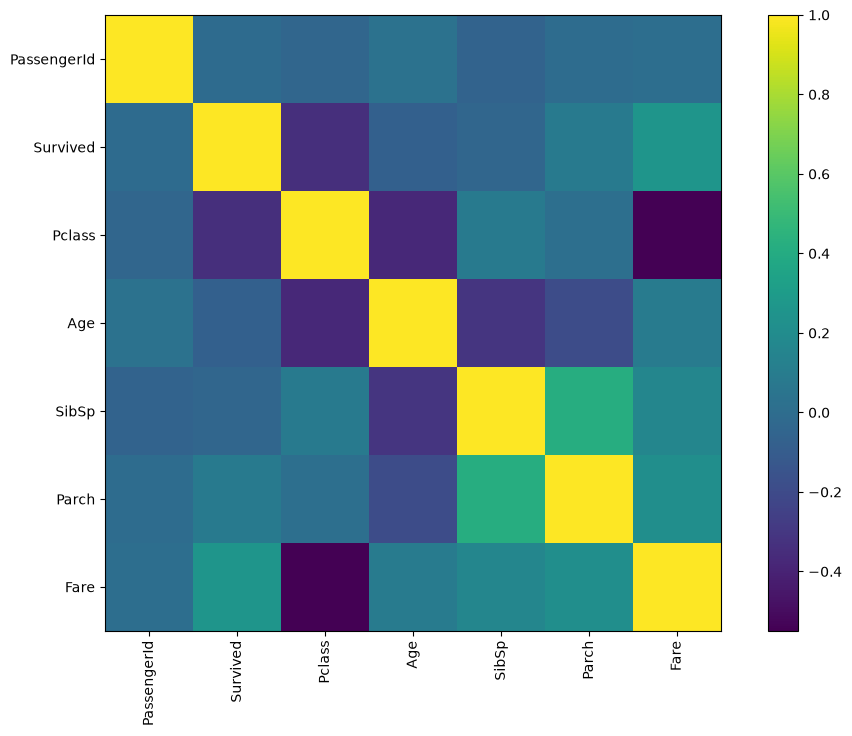

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

In [21]:
import seaborn as sns

<Axes: >

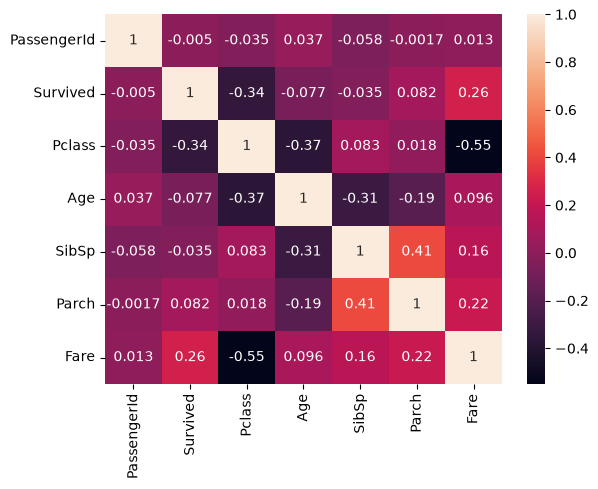

In [22]:
sns.heatmap(corr, annot=True)

In [23]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [24]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
# A professional pipeline should still be robust if another numeric feature unexpectedly contains missing values.
# Later we can decide whether this redundancy is necessary.

In [25]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
     ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [26]:
from sklearn.compose import ColumnTransformer

In [27]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [28]:
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

In [29]:
preprocessor.get_feature_names_out()

array(['num__Age', 'num__Pclass', 'num__SibSp', 'num__Parch', 'num__Fare',
       'num__FamilySize', 'num__IsAlone', 'num__CabinNotKnown',
       'num__TicketGroupSize', 'cat__Sex_female', 'cat__Sex_male',
       'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S',
       'cat__Embarked_Unknown', 'cat__Deck_A', 'cat__Deck_B',
       'cat__Deck_C', 'cat__Deck_D', 'cat__Deck_E', 'cat__Deck_F',
       'cat__Deck_G', 'cat__Deck_T', 'cat__Deck_Unknown',
       'cat__Title_Master.', 'cat__Title_Miss.', 'cat__Title_Mr.',
       'cat__Title_Mrs.', 'cat__Title_Rare'], dtype=object)

In [30]:
X_train_processed.shape

(712, 29)

In [31]:
X_test_processed.shape

(179, 29)

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
model_pipeline = Pipeline([
    ('features', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [34]:
model_pipeline.fit(X_train, y_train)

/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
Name,Type,Value
age_medians_,"Series[float64](3,)",Pclass 1 3...dtype: float64
common_titles_,"Index[object](4,)","Index(['Mr.',..., name='Name')"
ticket_counts_,"Series[int64](558,)","Ticket CA. 23..., dtype: int64"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [35]:
y_pred = model_pipeline.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
accuracy_score(y_test, y_pred)

0.8212290502793296

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



<Axes: >

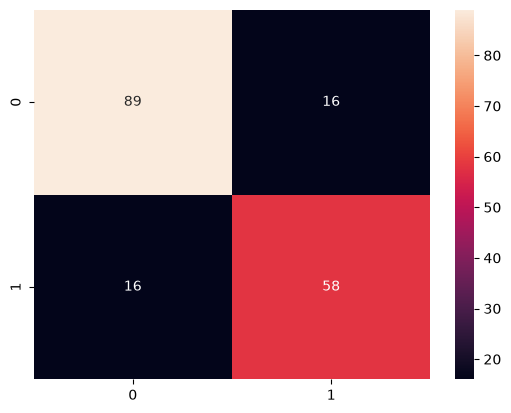

In [39]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [40]:
confusion_matrix(y_test, y_pred).ravel().tolist()

[89, 16, 16, 58]

In [41]:
confusion_matrix(y_test, y_pred)

array([[89, 16],
       [16, 58]])

In [42]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [44]:
scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

In [45]:
scores

array([0.82517483, 0.84615385, 0.85915493, 0.8028169 , 0.81690141])

In [46]:
scores.mean()

np.float64(0.8300403821530582)

In [47]:
scores.std()

np.float64(0.02022238745719358)

In [48]:
print(f'Cross Validation Score is: {scores.mean():.2f}±{scores.std():.2f}')

Cross Validation Score is: 0.83±0.02


In [49]:
import joblib

In [50]:
joblib.dump(model_pipeline, 'titanic_logist_pipeline.joblib')

['titanic_logist_pipeline.joblib']

In [51]:
model_saved = joblib.load('titanic_logist_pipeline.joblib')

In [52]:
model_saved.predict(X_test[:10])

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [53]:
y_test[:10].values

array([[1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1]])

In [54]:
from sklearn.model_selection import GridSearchCV

In [55]:
param_grid = {
    'model__C':[0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
# 'model__C':
# 'model' must match the pipeline's step name,
# and '__' connects the step name to the parameter name.

In [56]:
gridsearch = GridSearchCV(estimator=model_pipeline,
                          param_grid=param_grid,
                          scoring='accuracy',
                          cv=cv,
                          refit=True,
                         )
# refit = True, keeps the best model and train it.

In [57]:
gridsearch

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of i

In [58]:
gridsearch.fit(X_train, y_train)

/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of i

In [59]:
gridsearch.best_params_

{'model__C': 1}

In [60]:
gridsearch.best_score_

np.float64(0.8300403821530582)

In [61]:
results = pd.DataFrame(gridsearch.cv_results_)

In [62]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011959,0.001140,0.006248,0.000213,0.0001,{'model__C': 0.0001},0.622378,0.622378,0.626761,0.626761,0.619718,0.623599,0.002758,8
1,0.011011,0.000246,0.006027,0.000142,0.0010,{'model__C': 0.001},0.629371,0.636364,0.661972,0.640845,0.654930,0.644696,0.012019,7
2,0.019635,0.002423,0.010884,0.001936,0.0100,{'model__C': 0.01},0.797203,0.832168,0.816901,0.767606,0.774648,0.797705,0.024471,6
3,0.017882,0.005823,0.008884,0.002119,0.1000,{'model__C': 0.1},0.818182,0.839161,0.859155,0.795775,0.809859,0.824426,0.022340,2
4,0.025863,0.006173,0.009885,0.001916,1.0000,{'model__C': 1},0.825175,0.846154,0.859155,0.802817,0.816901,0.830040,0.020222,1
5,0.021993,0.004411,0.010141,0.001408,10.0000,{'model__C': 10},0.839161,0.832168,0.830986,0.795775,0.809859,0.821590,0.016205,5
6,0.030006,0.002809,0.010654,0.000841,100.0000,{'model__C': 100},0.839161,0.832168,0.823944,0.795775,0.816901,0.821590,0.014930,3
7,0.028354,0.003775,0.009256,0.001673,1000.0000,{'model__C': 1000},0.839161,0.832168,0.823944,0.795775,0.816901,0.821590,0.014930,3


In [63]:
results[['param_model__C', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False)

,param_model__C,mean_test_score,std_test_score
4,1.0000,0.830040,0.020222
3,0.1000,0.824426,0.022340
6,100.0000,0.821590,0.014930
7,1000.0000,0.821590,0.014930
5,10.0000,0.821590,0.016205
2,0.0100,0.797705,0.024471
1,0.0010,0.644696,0.012019
0,0.0001,0.623599,0.002758


In [64]:
best_model = gridsearch.best_estimator_
# as refit was the True, so we can have the best model (trained on best param)

In [65]:
best_model.predict(X_test)

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0])

In [69]:
from sklearn.tree import DecisionTreeClassifier

In [121]:
model_pipeline_tree = Pipeline([
    ('features', featureEngineer),
    ('preprocessor', preprocessor),
    ('model_tree', DecisionTreeClassifier(max_depth=10,random_state=42))
])

In [122]:
model_pipeline_tree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
Name,Type,Value
age_medians_,"Series[float64](3,)",Pclass 1 3...dtype: float64
common_titles_,"Index[object](4,)","Index(['Mr.',..., name='Name')"
ticket_counts_,"Series[int64](558,)","Ticket CA. 23..., dtype: int64"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [123]:
y_pred_tree = model_pipeline_tree.predict(X_test)

In [124]:
accuracy_score(y_test, y_pred_tree)

0.7932960893854749

In [125]:
scores_tree = cross_val_score(model_pipeline_tree, X_train, y_train, cv = cv, scoring = 'accuracy')

In [126]:
scores_tree

array([0.78321678, 0.78321678, 0.82394366, 0.74647887, 0.78873239])

In [127]:
scores_tree.mean()

np.float64(0.7851176992022062)

In [128]:
scores_tree.std()

np.float64(0.024579289009510993)

In [129]:
print(f'Cross validation score is: {scores_tree.mean():.2f}±{scores_tree.std():.2f}')

Cross validation score is: 0.79±0.02


In [130]:
param_grid_tree = {
    'model_tree__max_depth': [2,3,4,5, 6, 8, 10, None],
    'model_tree__min_samples_split': [2,5,10,15,20],
    'model_tree__min_samples_leaf': [1,2,5,10],
}

In [131]:
gridsearch_tree = GridSearchCV(estimator=model_pipeline_tree, param_grid=param_grid_tree, scoring='accuracy', refit=True, cv=cv)

In [132]:
gridsearch_tree

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model_tree__max_depth': [2, 3, ...], 'model_tree__min_samples_leaf': [1, 2, ...], 'model_tree__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20

In [133]:
gridsearch_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model_tree__max_depth': [2, 3, ...], 'model_tree__min_samples_leaf': [1, 2, ...], 'model_tree__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20

In [134]:
gridsearch_tree.best_score_

np.float64(0.8202501723628485)

In [135]:
gridsearch_tree.best_params_

{'model_tree__max_depth': 8,
 'model_tree__min_samples_leaf': 2,
 'model_tree__min_samples_split': 15}

In [136]:
best_model_tree = gridsearch_tree.best_estimator_

In [137]:
y_pred_tree = best_model_tree.predict(X_test)

In [138]:
accuracy_score(y_test, y_pred_tree)

0.8268156424581006

In [142]:
results_tree = pd.DataFrame(gridsearch_tree.cv_results_)
results_tree.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_model_tree__max_depth', 'param_model_tree__min_samples_leaf',
       'param_model_tree__min_samples_split', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'mean_test_score', 'std_test_score',
       'rank_test_score'],
      dtype='str')

In [143]:
best_row = results_tree.loc[gridsearch_tree.best_index_]

In [144]:
best_row

mean_fit_time                                                                   0.011019
std_fit_time                                                                    0.000515
mean_score_time                                                                 0.006064
std_score_time                                                                  0.000236
param_model_tree__max_depth                                                            8
param_model_tree__min_samples_leaf                                                     2
param_model_tree__min_samples_split                                                   15
params                                 {'model_tree__max_depth': 8, 'model_tree__min_...
split0_test_score                                                               0.776224
split1_test_score                                                               0.846154
split2_test_score                                                               0.852113
split3_test_score    

In [148]:
print(f'Best CV mean:{best_row['mean_test_score']:.2f}')
print(f'Best CV std: {best_row['std_test_score']:.2f}')

Best CV mean:0.82
Best CV std: 0.03


In [149]:
from sklearn.ensemble import RandomForestClassifier

In [150]:
model_pipeline_RF = Pipeline([
    ('features', featureEngineer),
    ('preprocessor', preprocessor),
    ('model_RF', RandomForestClassifier()),
])

In [153]:
scores_RF = cross_val_score(model_pipeline_RF, X_train, y_train, cv = cv, scoring='accuracy')

/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change

In [154]:
scores_RF

array([0.7972028 , 0.83916084, 0.8028169 , 0.78873239, 0.80985915])

In [170]:
param_grid_RF = {
    'model_RF__n_estimators': [100, 300],
    'model_RF__max_depth': [5,10, None],
    'model_RF__min_samples_split': [2,10],
    'model_RF__min_samples_leaf': [1,5],
}

In [171]:
gridsearch_RF = GridSearchCV(model_pipeline_RF, param_grid_RF, scoring='accuracy', cv=cv, refit = True)

In [172]:
gridsearch_RF.fit(X_train, y_train)

/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model_RF__max_depth': [5, 10, ...], 'model_RF__min_samples_leaf': [1, 5], 'model_RF__min_samples_split': [2, 10], 'model_RF__n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score.

In [173]:
gridsearch_RF.best_params_

{'model_RF__max_depth': None,
 'model_RF__min_samples_leaf': 1,
 'model_RF__min_samples_split': 10,
 'model_RF__n_estimators': 100}

In [174]:
gridsearch_RF.best_score_

np.float64(0.8384812370727863)

In [175]:
rf_results = pd.DataFrame(gridsearch_RF.cv_results_)

best_rf_row = rf_results.loc[
    gridsearch_RF.best_index_
]

print(f"Best RF CV mean: {best_rf_row['mean_test_score']:.3f}")
print(f"Best RF CV std:  {best_rf_row['std_test_score']:.3f}")

Best RF CV mean: 0.838
Best RF CV std:  0.021


### Evaluation

In [176]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'CV Mean': [
        0.830,
        0.820,
        best_rf_row['mean_test_score']
    ],
    'CV Std': [
        0.020,
        0.030,
        best_rf_row['std_test_score']
    ]
})

model_results

,Model,CV Mean,CV Std
0,Logistic Regression,0.830000,0.020000
1,Decision Tree,0.820000,0.030000
2,Random Forest,0.838481,0.021264


In [180]:
best_rf_model = gridsearch_RF.best_estimator_

In [181]:
y_test_pred = best_rf_model.predict(X_test)

In [182]:
from sklearn.metrics import accuracy_score, classification_report

In [186]:
print(f'Test Accuracy: {accuracy_score(y_test, y_test_pred)}')

Test Accuracy: 0.8379888268156425


In [187]:
print(classification_report(y_test,  y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       105
           1       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [188]:
import joblib

In [189]:
joblib.dump(best_rf_model, 'titanic-RF.pkl')

['titanic-RF.pkl']

In [192]:
rf = best_rf_model.named_steps['model_RF']

In [206]:
rf.feature_importances_

array([1.09058937e-01, 6.34196817e-02, 2.41655444e-02, 1.56199931e-02,
       1.35130557e-01, 4.76746646e-02, 9.09090121e-03, 2.84098337e-02,
       4.44335503e-02, 1.27426349e-01, 1.03135060e-01, 9.61115596e-03,
       6.80003480e-03, 1.29837581e-02, 1.88592676e-07, 2.07245382e-03,
       6.46352010e-03, 4.01229515e-03, 3.57569834e-03, 1.11341293e-02,
       1.63611360e-03, 2.40673509e-03, 2.46524903e-04, 2.03960659e-02,
       1.07534751e-02, 2.31965658e-02, 1.28302587e-01, 4.28710607e-02,
       5.97256531e-03])

In [207]:
feature_names = (best_rf_model.named_steps['preprocessor'].get_feature_names_out())

In [208]:
feature_names

array(['num__Age', 'num__Pclass', 'num__SibSp', 'num__Parch', 'num__Fare',
       'num__FamilySize', 'num__IsAlone', 'num__CabinNotKnown',
       'num__TicketGroupSize', 'cat__Sex_female', 'cat__Sex_male',
       'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S',
       'cat__Embarked_Unknown', 'cat__Deck_A', 'cat__Deck_B',
       'cat__Deck_C', 'cat__Deck_D', 'cat__Deck_E', 'cat__Deck_F',
       'cat__Deck_G', 'cat__Deck_T', 'cat__Deck_Unknown',
       'cat__Title_Master.', 'cat__Title_Miss.', 'cat__Title_Mr.',
       'cat__Title_Mrs.', 'cat__Title_Rare'], dtype=object)

In [209]:
importance_df = pd.DataFrame({
    'Feature':feature_names,
    'Importance':rf.feature_importances_
})

In [210]:
importance_df = importance_df.sort_values('Importance', ascending=False)

In [211]:
importance_df.head(15)

,Feature,Importance
4,num__Fare,0.135131
26,cat__Title_Mr.,0.128303
9,cat__Sex_female,0.127426
0,num__Age,0.109059
10,cat__Sex_male,0.103135
1,num__Pclass,0.063420
5,num__FamilySize,0.047675
8,num__TicketGroupSize,0.044434
27,cat__Title_Mrs.,0.042871
7,num__CabinNotKnown,0.028410


In [231]:
# Feature importance: shows how much each feature contributes to reducing impurity across the Random Forest trees.

In [212]:
top_features = importance_df.head(15).sort_values('Importance')

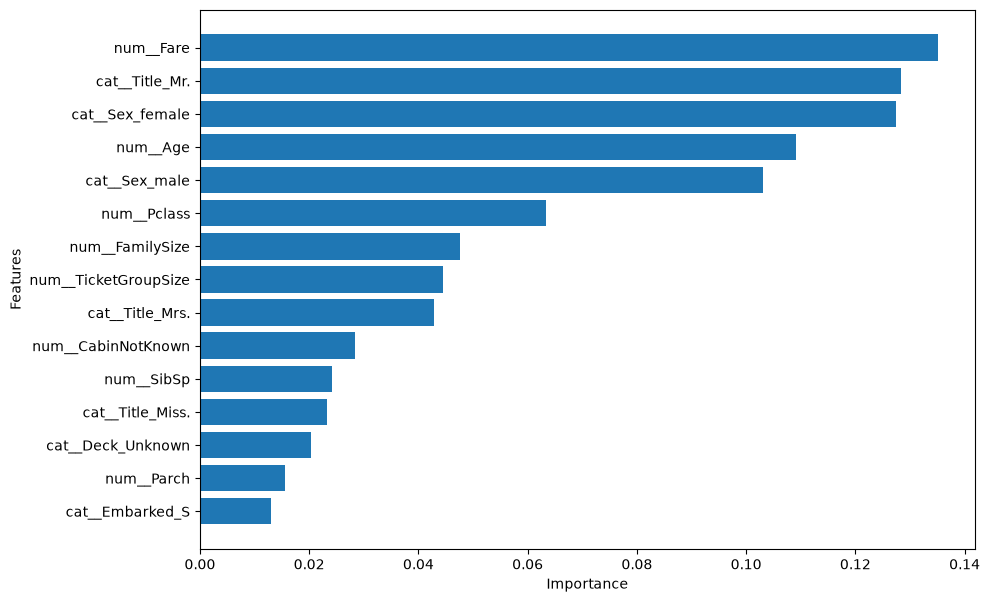

In [222]:
plt.figure(figsize=(10,7))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [223]:
from sklearn.inspection import permutation_importance

In [232]:
# Permutation importance: measures how much model performance decreases when a feature's values are randomly shuffled.
# Permutation importance is often more intuitive, but correlated features can make its interpretation less straightforward.

In [225]:
perm_result = permutation_importance(best_rf_model,
                                    X_test, y_test,
                                     scoring = 'accuracy',
                                     n_repeats=20,
                                     random_state=42
                                    )

In [226]:
perm_result

{'importances_mean': array([0.        , 0.00530726, 0.02486034, 0.08351955, 0.00363128,
        0.01424581, 0.01256983, 0.00586592, 0.00921788, 0.02597765,
        0.02877095]),
 'importances_std': array([0.        , 0.00959122, 0.00873994, 0.0194711 , 0.00593206,
        0.00623975, 0.00681358, 0.00373718, 0.00870415, 0.00833788,
        0.00888163]),
 'importances': array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [-0.01117318,  0.00558659,  0.00558659,  0.00558659,  0.00558659,
          0.01117318,  0.01675978,  0.01117318, -0.00558659,  0.01675978,
          0.01675978,  0.00558659,  0.00558659, -0.01117318,  0.01675978,
         -0.01117318,  0.        ,  0.01675978, -0.00558659,  0.01117318],
        [ 0.03910615,  0.02234637,  

In [227]:
perm_df = pd.DataFrame({
    'Feature':X_test.columns,
    'Importance': perm_result['importances_mean'],
    'Std': perm_result['importances_std']
})

In [230]:
perm_df.head(15).sort_values('Importance', ascending=False)

,Feature,Importance,Std
3,Sex,0.083520,0.019471
10,Embarked,0.028771,0.008882
9,Cabin,0.025978,0.008338
2,Name,0.024860,0.008740
5,SibSp,0.014246,0.006240
6,Parch,0.012570,0.006814
8,Fare,0.009218,0.008704
7,Ticket,0.005866,0.003737
1,Pclass,0.005307,0.009591
4,Age,0.003631,0.005932


### Gradient Boosting

In [233]:
from sklearn.ensemble import GradientBoostingClassifier

In [243]:
model_pipeline_GB = Pipeline([
    ('feature', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model_GB', GradientBoostingClassifier(random_state=42)),
])

In [244]:
scores_GB = cross_val_score(model_pipeline_GB, X_train, y_train, cv=cv, scoring='accuracy')

/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expec

In [245]:
scores_GB.mean()

np.float64(0.8385107849896581)

In [247]:
print(f'Cross validation score is {scores_GB.mean():.3f}±{scores_GB.std():.3f}')

Cross validation score is 0.839±0.034


In [ ]:
# param_grid_GB = {
#     'model_GB__n_estimators': [50, 100, 200],
#     'model_GB__learning_rate': [0.01, 0.05, 0.1],
#     'model_GB__max_depth': [1, 2, 3],
#     'model_GB__min_samples_split': [2, 5, 10],
#     'model_GB__min_samples_leaf': [1, 2, 5]
# }

In [248]:
param_grid_GB = {
    'model_GB__n_estimators': [50, 100, 200],
    'model_GB__learning_rate': [0.05, 0.1],
    'model_GB__max_depth': [1, 2, 3],
}

In [249]:
gridsearch_GB = GridSearchCV(model_pipeline_GB, param_grid_GB, scoring='accuracy', refit=True, cv=cv)

In [250]:
gridsearch_GB.fit(X_train, y_train)

/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/arshia/torch_env/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expec

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model_GB__learning_rate': [0.05, 0.1], 'model_GB__max_depth': [1, 2, ...], 'model_GB__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

In [251]:
gridsearch_GB.best_score_

np.float64(0.8385107849896581)

In [252]:
gridsearch_GB.best_params_

{'model_GB__learning_rate': 0.1,
 'model_GB__max_depth': 3,
 'model_GB__n_estimators': 100}

In [253]:
results_GB = pd.DataFrame(gridsearch_GB.cv_results_)

In [254]:
results_GB

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model_GB__learning_rate,param_model_GB__max_depth,param_model_GB__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.030233,0.003878,0.006475,0.000442,0.05,1,50,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.748252,0.839161,0.852113,0.781690,0.809859,0.806215,0.037859,18
1,0.046358,0.001542,0.006755,0.000339,0.05,1,100,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.790210,0.853147,0.852113,0.781690,0.816901,0.818812,0.029959,16
2,0.083312,0.001005,0.006850,0.000236,0.05,1,200,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.790210,0.860140,0.866197,0.788732,0.823944,0.825845,0.033031,14
3,0.035140,0.000341,0.006449,0.000375,0.05,2,50,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.783217,0.874126,0.866197,0.795775,0.830986,0.830060,0.036382,12
4,0.058226,0.000695,0.006783,0.000308,0.05,2,100,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.790210,0.860140,0.866197,0.809859,0.823944,0.830070,0.029135,11
5,0.107777,0.001808,0.006926,0.000326,0.05,2,200,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.811189,0.853147,0.866197,0.802817,0.859155,0.838501,0.026182,2
6,0.041187,0.000963,0.006364,0.000370,0.05,3,50,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.790210,0.853147,0.866197,0.823944,0.823944,0.831488,0.026426,8
7,0.072084,0.000599,0.006689,0.000341,0.05,3,100,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.818182,0.846154,0.859155,0.795775,0.852113,0.834276,0.023747,4
8,0.135290,0.002717,0.007016,0.000263,0.05,3,200,"{'model_GB__learning_rate': 0.05, 'model_GB__m...",0.818182,0.839161,0.845070,0.788732,0.873239,0.832877,0.028221,6
9,0.027969,0.000204,0.006285,0.000303,0.10,1,50,"{'model_GB__learning_rate': 0.1, 'model_GB__ma...",0.790210,0.853147,0.852113,0.781690,0.816901,0.818812,0.029959,16


In [255]:
best_row_GB = results_GB.loc[gridsearch_GB.best_index_]

In [262]:
print(f'Best GB CV mean: {best_row_GB.mean_test_score:.3f}')
print(f'Best GB CV std: {best_row_GB.std_test_score:.3f}')

Best GB CV mean: 0.839
Best GB CV std: 0.034


In [263]:
best_model_GB = gridsearch_GB.best_estimator_

In [264]:
y_pred_GB = best_model_GB.predict(X_test)

In [268]:
print(f'Gradient Boosting Test Accuracy: {accuracy_score(y_test, y_pred_GB):.3f}')

Gradient Boosting Test Accuracy: 0.821


In [269]:
print(classification_report(y_test, y_pred_GB))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [15]:
from sklearn.metrics import confusion_matrix

In [283]:
confusion_matrix = confusion_matrix(y_test, y_test_pred)

In [284]:
import seaborn as sns

<Axes: >

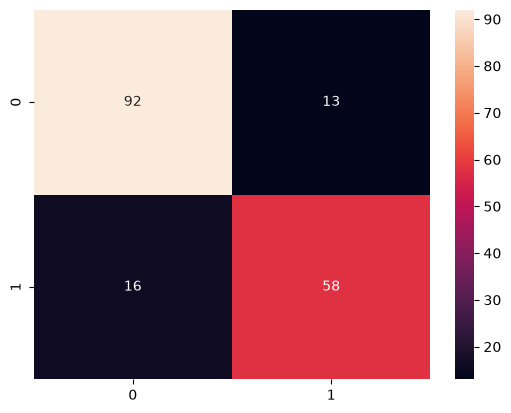

In [285]:
sns.heatmap(confusion_matrix, annot = True)

In [286]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       105
           1       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



## Using  the saved model

In [1]:
import joblib
import sklearn

In [12]:
model = joblib.load('titanic-RF.pkl')

In [14]:
y_pred_RF = model.predict(X_test)

In [16]:
confusion_matrix(y_test, y_pred_RF)

array([[92, 13],
       [16, 58]])

In [18]:
errors = X_test.copy()

In [19]:
errors['Actual'] = y_test.values
errors['Predicted'] = y_pred_RF

In [20]:
errors

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Actual,Predicted
709,710,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C,1,1
439,440,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S,0,0
840,841,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S,0,0
720,721,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S,1,1
39,40,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,434,3,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,STON/O 2. 3101274,7.1250,NaN,S,0,0
773,774,3,"Elias, Mr. Dibo",male,NaN,0,0,2674,7.2250,NaN,C,0,0
25,26,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S,1,0
84,85,2,"Ilett, Miss. Bertha",female,17.0,0,0,SO/C 14885,10.5000,NaN,S,1,1


In [21]:
errors['Correct'] = (errors['Actual'] == errors['Predicted'])

In [22]:
errors

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Actual,Predicted,Correct
709,710,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C,1,1,True
439,440,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S,0,0,True
840,841,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S,0,0,True
720,721,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S,1,1,True
39,40,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C,1,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,434,3,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,STON/O 2. 3101274,7.1250,NaN,S,0,0,True
773,774,3,"Elias, Mr. Dibo",male,NaN,0,0,2674,7.2250,NaN,C,0,0,True
25,26,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S,1,0,False
84,85,2,"Ilett, Miss. Bertha",female,17.0,0,0,SO/C 14885,10.5000,NaN,S,1,1,True


In [24]:
errors = errors[~errors['Correct']]

In [26]:
errors.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Actual,Predicted,Correct
621,622,1,"Kimball, Mr. Edwin Nelson Jr",male,42.0,1,0,11753,52.5542,D19,S,1,0,False
447,448,1,"Seward, Mr. Frederic Kimber",male,34.0,0,0,113794,26.5500,NaN,S,1,0,False
192,193,3,"Andersen-Jensen, Miss. Carla Christine Nielsine",female,19.0,1,0,350046,7.8542,NaN,S,1,0,False
673,674,2,"Wilhelms, Mr. Charles",male,31.0,0,0,244270,13.0000,NaN,S,1,0,False
141,142,3,"Nysten, Miss. Anna Sofia",female,22.0,0,0,347081,7.7500,NaN,S,1,0,False
